In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import geopandas as gpd
from shapely.geometry import MultiPoint
import xarray as xr
import matplotlib.pyplot as plt
import os
import re
import datetime
import zipfile

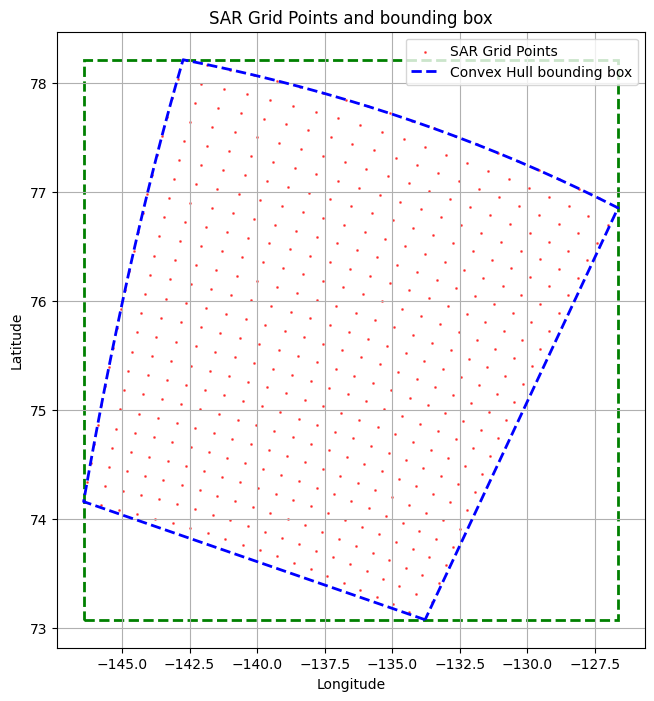

In [ ]:
# Test Data Visualization
ds = xr.open_dataset("./AI4Arctic/S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.nc")

lat = ds['sar_grid_latitude'].values
lon = ds['sar_grid_longitude'].values
lat_flat = lat.flatten()
lon_flat = lon.flatten()
valid_mask = np.isfinite(lat_flat) & np.isfinite(lon_flat)
lat_flat = lat_flat[valid_mask]
lon_flat = lon_flat[valid_mask]

# extract regular bounding box
min_lon, max_lon = np.min(lon_flat), np.max(lon_flat)
min_lat, max_lat = np.min(lat_flat), np.max(lat_flat)
bbox_width = max_lon - min_lon
bbox_height = max_lat - min_lat

# extract convex_hull bounding box
points = MultiPoint(list(zip(lon_flat, lat_flat)))
hull = points.convex_hull  
gdf = gpd.GeoDataFrame(index=[0], geometry=[hull], crs="EPSG:4326")

#plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(lon_flat, lat_flat, s=1, color='red', label="SAR Grid Points", alpha=0.6)
bbox = Rectangle((min_lon, min_lat), bbox_width, bbox_height, linewidth=2, edgecolor='green', facecolor='none', linestyle='--',)
ax.add_patch(bbox)
gdf.boundary.plot(ax=ax, color='blue', linewidth=2, linestyle='--', label="Convex Hull bounding box")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("SAR Grid Points and bounding box")
ax.grid(True)
ax.legend()
plt.show()


In [6]:
# create Sentinel-1 shapefiles 
folder_path = "./AI4Arctic"
output_folder = "AI4Arctic_shapefiles"
os.makedirs(output_folder, exist_ok=True)
nc_files = sorted([f for f in os.listdir(folder_path) if f.endswith(".nc")])

for i, filename in enumerate(nc_files, start=1):
    file_path = os.path.join(folder_path, filename)
    print(f"\nProcessing file {i}/{len(nc_files)}: {filename}")
    try:
        # extract acquisition start/stop time from filename
        match = re.search(r'(\d{8}T\d{6})_(\d{8}T\d{6})', filename)
        if match:
            start_raw, stop_raw = match.groups()
            # convert to datetime
            start_dt = datetime.datetime.strptime(start_raw, "%Y%m%dT%H%M%S")
            stop_dt = datetime.datetime.strptime(stop_raw, "%Y%m%dT%H%M%S")
            acquisition_date = start_dt.strftime("%Y-%m-%d")
            start_time = start_dt.strftime("%H:%M:%S")
            stop_time = stop_dt.strftime("%H:%M:%S")
            print(f"Acquisition Date      : {acquisition_date}")
            print(f"Acquisition Start Time: {start_time}")
            print(f"Acquisition Stop Time : {stop_time}")

        # extract bounding box polygon
        ds = xr.open_dataset(file_path)
        lat = ds['sar_grid_latitude'].values
        lon = ds['sar_grid_longitude'].values
        lat_flat = lat.flatten()
        lon_flat = lon.flatten()
        valid_mask = np.isfinite(lat_flat) & np.isfinite(lon_flat)
        lat_flat = lat_flat[valid_mask]
        lon_flat = lon_flat[valid_mask]
        points = MultiPoint(list(zip(lon_flat, lat_flat)))
        hull = points.convex_hull  

        # save & create shapefiles
        gdf = gpd.GeoDataFrame({'filename': [filename]}, geometry=[hull], crs="EPSG:4326")
        shapefile_base = os.path.splitext(filename)[0]
        shapefile_path = os.path.join(output_folder, shapefile_base + ".shp")
        gdf.to_file(shapefile_path)
        zip_filename = f"{i:02d}_{shapefile_base}.zip"
        zip_path = os.path.join(output_folder, zip_filename)
        with zipfile.ZipFile(zip_path, 'w') as zipf:
            for ext in ['.shp', '.shx', '.dbf', '.cpg', '.prj']:
                file = os.path.join(output_folder, shapefile_base + ext)
                if os.path.exists(file):
                    zipf.write(file, arcname=os.path.basename(file))

        # remove temporary shapefile components
        for ext in ['.shp', '.shx', '.dbf', '.cpg', '.prj']:
            file = os.path.join(output_folder, shapefile_base + ext)
            if os.path.exists(file):
                os.remove(file)

    except Exception as e:
        print(f"Failed to process {filename}: {e}")


Processing file 1/22: S1A_EW_GRDM_1SDH_20190819T153633_20190819T153733_028640_033D98_D165_icechart_cis_SGRDIWA_20190819T1533Z_pl_a.nc
Acquisition Date      : 2019-08-19
Acquisition Start Time: 15:36:33
Acquisition Stop Time : 15:37:33

Processing file 2/22: S1A_EW_GRDM_1SDH_20190826T152818_20190826T152918_028742_034127_A43C_icechart_cis_SGRDIWA_20190826T1528Z_pl_a.nc
Acquisition Date      : 2019-08-26
Acquisition Start Time: 15:28:18
Acquisition Stop Time : 15:29:18

Processing file 3/22: S1A_EW_GRDM_1SDH_20190826T152918_20190826T153017_028742_034127_DB68_icechart_cis_SGRDIWA_20190826T1528Z_pl_a.nc
Acquisition Date      : 2019-08-26
Acquisition Start Time: 15:29:18
Acquisition Stop Time : 15:30:17

Processing file 4/22: S1A_EW_GRDM_1SDH_20190922T155200_20190922T155300_029136_034EBF_8E7C_icechart_cis_SGRDIWA_20190922T1539Z_pl_a.nc
Acquisition Date      : 2019-09-22
Acquisition Start Time: 15:52:00
Acquisition Stop Time : 15:53:00

Processing file 5/22: S1A_EW_GRDM_1SDH_20190922T155400_